# Mistura gaussiana em dados sintéticos

**Autor:** Prof. Dr. Sergio Antônio Andrade de Freitas  
**Material da disciplina:** FGA0083 — Aprendizado de Máquina, UnB

## Objetivo e dados

Visualizar centros e probabilidades de pertinência.

**Pergunta-guia:** Quais pontos têm classificação mais incerta?

Execute as células na ordem e interprete os resultados antes de fazer o exercício.

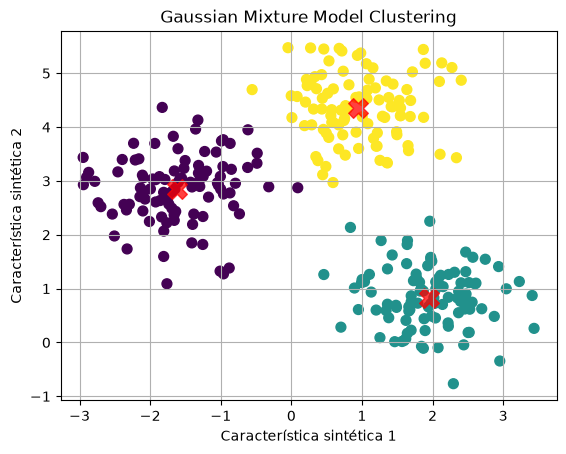

Menor confiança em uma atribuição: 0.514


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_blobs

# Gerar dados de exemplo (altura e peso)
X, _ = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=0)

# Aplicar GMM
gmm = GaussianMixture(n_components=3, random_state=0)
gmm.fit(X)
y_gmm = gmm.predict(X)

# Visualizar os dados e os clusters
plt.scatter(X[:, 0], X[:, 1], c=y_gmm, s=50, cmap='viridis')
centers = gmm.means_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X')
plt.title('Gaussian Mixture Model Clustering')
plt.xlabel('Característica sintética 1')
plt.ylabel('Característica sintética 2')
plt.grid(True)
plt.show()

prob = gmm.predict_proba(X)
print('Menor confiança em uma atribuição:', round(prob.max(axis=1).min(), 3))

## Investigação complementar

Compare a nova medida com a figura ou o resultado anterior. Explique qualquer diferença observada.

In [2]:
for k in (2, 3, 4):
    candidato = GaussianMixture(n_components=k, random_state=0).fit(X)
    print(f'componentes={k}: BIC={candidato.bic(X):.1f}')

componentes=2: BIC=1905.1
componentes=3: BIC=1828.7
componentes=4: BIC=1863.2


## Interpretação e limites

As componentes são gaussianas estimadas, não categorias necessariamente reais.

## Exercício

Compare com K-means e varie o número de componentes.

Registre a hipótese, a mudança realizada, a métrica ou figura observada e uma conclusão que os dados de fato sustentem.